<h1 style="color:#38BDF8; text-align:center; font-weight:bold; border-bottom:3px solid #38BDF8;">Day 5 — EDA Part 2: Correlation &amp; Data Storytelling</h1>
<h3 style="text-align:center; color:#BE185D;">Bivariate Analysis, Correlation Heatmaps &amp; the Complete Week 2 EDA Notebook</h3>


<h2 style="color:#BE185D; font-weight:bold; margin-top:30px;">Table of Contents</h2>

<div style="border:1px solid #ccc; padding:15px 25px; border-radius:6px;">
<ol style="font-weight:bold; line-height:1.9;">
<li><a href="#section0">0. Setup — Importing Seaborn, Pandas, NumPy &amp; Matplotlib</a></li>
<li><a href="#section1">1. Bivariate Analysis — Scatter Plots &amp; Grouped Box Plots</a></li>
<li><a href="#section2">2. Correlation &amp; the Correlation Heatmap</a></li>
<li><a href="#section3">3. Correlation Is Not Causation</a></li>
<li><a href="#section4">4. The Pairplot — Scanning All Relationships at Once</a></li>
<li><a href="#section5">5. Data Storytelling — Turning Analysis into a Narrative</a></li>
<li><a href="#section6">6. Common Mistakes to Avoid</a></li>
<li><a href="#section7">7. Quick Reference — Cheat Sheet</a></li>
<li><a href="#section8">8. Hands-On Lab — Complete EDA Notebook</a></li>
<li><a href="#section9">9. Best Practices &amp; Reproducibility</a></li>
<li><a href="#section10">10. Summary — What I Learned Today</a></li>
</ol>
</div>


<a id="section0"></a>
<h2 style="color:#BE185D; font-weight:bold; margin-top:30px;">0. Setup — Importing Seaborn, Pandas, NumPy &amp; Matplotlib</h2>

<div style="border-left:5px solid #38BDF8; background-color:#eaf6ff; padding:10px 15px; margin:10px 0; border-radius:4px; color:#0c4a6e;">
<b>Note:</b> Today's toolbox is exactly the same as Day 4 — <b>Seaborn</b> is still our primary visualization tool, now used to explore <b>relationships between variables</b> rather than single variables on their own.
</div>


In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

print("Seaborn version   :", sns.__version__)
print("Pandas version    :", pd.__version__)
print("NumPy version     :", np.__version__)
print("Matplotlib version:", plt.matplotlib.__version__)

sns.set_style("whitegrid")

Seaborn version   : 0.13.2
Pandas version    : 2.3.3
NumPy version     : 2.3.5
Matplotlib version: 3.10.6


<div style="border-left:5px solid #4ADE80; background-color:#eafff2; padding:10px 15px; margin:10px 0; border-radius:4px; color:#065f46;">
<b>Tip:</b> We rebuild the same sample "interns" dataset from Day 4 (same random seed), so today's bivariate analysis connects directly to yesterday's univariate findings.
</div>

In [2]:
np.random.seed(42)

n = 200
df = pd.DataFrame({
    "name": [f"intern_{i}" for i in range(n)],
    "track": np.random.choice(["AI & ML", "Web Dev", "Cybersecurity", "Data Analysis"],
                               size=n, p=[0.4, 0.3, 0.15, 0.15]),
    "age": np.random.normal(23, 2.5, n).round().astype(int),
    "weekly_hours": np.random.normal(39, 3, n).round(1),
    "monthly_stipend": np.random.normal(400, 60, n).round(),
})

# Give stipend a genuine relationship with weekly_hours, so today's correlation analysis has
# something real to find -- more hours logged tends to mean a somewhat higher stipend.
df["monthly_stipend"] = df["monthly_stipend"] + (df["weekly_hours"] - 39) * 8

# the same deliberate outliers from Day 4, for continuity
df.loc[3, "weekly_hours"] = 70
df.loc[15, "monthly_stipend"] = 1500
df.loc[42, "age"] = 45

df.head()

,name,track,age,weekly_hours,monthly_stipend
0,intern_0,AI & ML,21,41.6,490.8
1,intern_1,Data Analysis,24,38.5,411.0
2,intern_2,Cybersecurity,24,38.9,419.2
3,intern_3,Web Dev,21,70.0,351.0
4,intern_4,AI & ML,28,38.9,370.2


<a id="section1"></a>
<h2 style="color:#BE185D; font-weight:bold; margin-top:30px;">1. Bivariate Analysis — Scatter Plots &amp; Grouped Box Plots</h2>

<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">1.1 What "bivariate" means</h3>

<b>Bivariate analysis</b> examines the relationship <b>between two variables</b> — the step where genuine insight usually appears, because ML is fundamentally about relationships between features and a target. This is a direct continuation of Day 4's univariate analysis, which looked at variables one at a time.

<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">1.2 Scatter plots — two numeric variables</h3>

A scatter plot reveals the relationship between <b>two numeric variables</b> — exactly like the scatter plots from Matplotlib in Week 1, but Seaborn adds statistical convenience features on top.


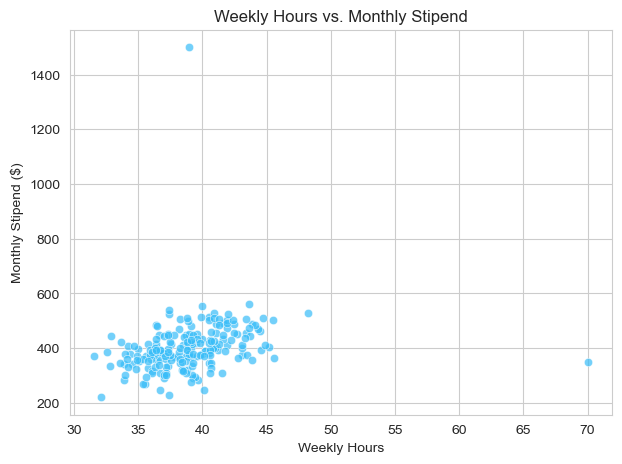

In [3]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x="weekly_hours", y="monthly_stipend", color="#38BDF8", alpha=0.7)
plt.xlabel("Weekly Hours")
plt.ylabel("Monthly Stipend ($)")
plt.title("Weekly Hours vs. Monthly Stipend")
plt.show()

<div style="border-left:5px solid #4ADE80; background-color:#eafff2; padding:10px 15px; margin:10px 0; border-radius:4px; color:#065f46;">
<b>Tip:</b> There's a visible upward trend — interns who log more hours tend to have a somewhat higher stipend. We'll measure exactly how strong this relationship is with correlation in the next section.
</div>

<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">1.3 Adding a <code>hue</code> for a third variable</h3>

Seaborn makes it easy to add a third dimension to a scatter plot by coloring points according to a categorical variable, using the <code>hue</code> parameter.


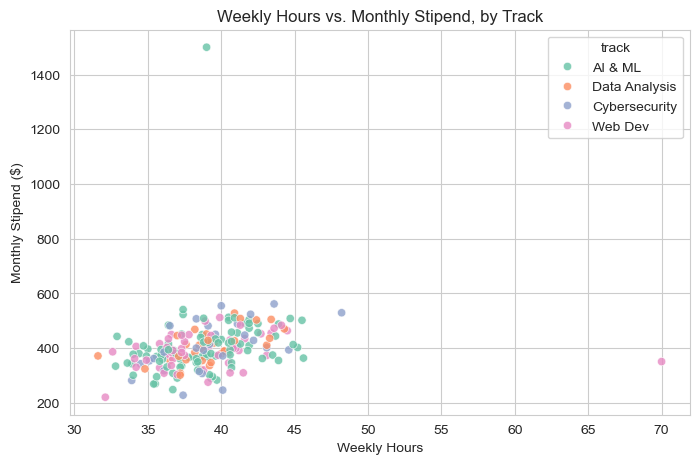

In [4]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="weekly_hours", y="monthly_stipend", hue="track", palette="Set2", alpha=0.8)
plt.xlabel("Weekly Hours")
plt.ylabel("Monthly Stipend ($)")
plt.title("Weekly Hours vs. Monthly Stipend, by Track")
plt.show()

<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">1.4 Grouped box plots — a numeric variable across categories</h3>

Grouped box plots reveal how a <b>numeric</b> variable differs across <b>categories</b> — combining Day 1's quartile ideas with Day 4's box plots and category comparison.


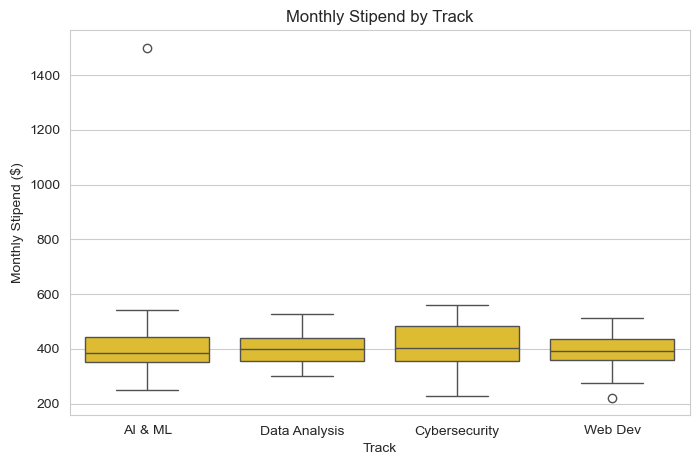

In [5]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="track", y="monthly_stipend", color="#FACC15")
plt.xlabel("Track")
plt.ylabel("Monthly Stipend ($)")
plt.title("Monthly Stipend by Track")
plt.show()

<div style="border-left:5px solid #38BDF8; background-color:#eaf6ff; padding:10px 15px; margin:10px 0; border-radius:4px; color:#0c4a6e;">
<b>Note:</b> Reading a grouped box plot: each box shows the median and IQR of monthly stipend <i>within that one track</i> — so you can directly compare, for example, whether "AI &amp; ML" interns tend to have a higher or more variable stipend than "Cybersecurity" interns.
</div>

<a id="section2"></a>
<h2 style="color:#BE185D; font-weight:bold; margin-top:30px;">2. Correlation &amp; the Correlation Heatmap</h2>

<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">2.1 What correlation measures</h3>

<b>Correlation</b> measures how strongly two numeric variables move together, on a scale from <b>-1 to +1</b>:

<ul>
<li><b>+1</b> — a perfect positive relationship (as one goes up, the other always goes up)</li>
<li><b>-1</b> — a perfect negative relationship (as one goes up, the other always goes down)</li>
<li><b>0</b> — no linear relationship at all</li>
</ul>


In [6]:
correlation_value = df["weekly_hours"].corr(df["monthly_stipend"])
print(f"Correlation between weekly_hours and monthly_stipend: {correlation_value:.3f}")

Correlation between weekly_hours and monthly_stipend: 0.219


<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">2.2 The correlation heatmap</h3>

A <b>correlation heatmap</b> shows every pair of variables' correlations at once — one of the most informative single charts in all of EDA.


                      age  weekly_hours  monthly_stipend
age              1.000000      -0.03747         0.082767
weekly_hours    -0.037470       1.00000         0.219490
monthly_stipend  0.082767       0.21949         1.000000


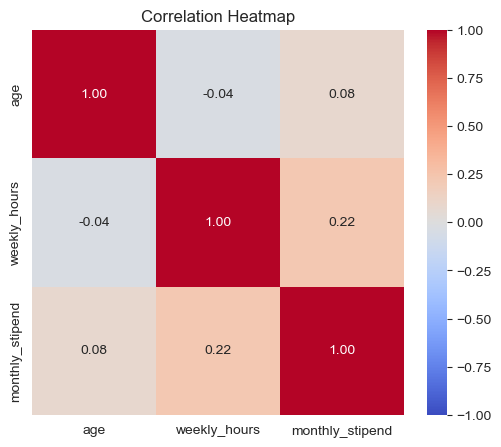

In [7]:
numeric_df = df[["age", "weekly_hours", "monthly_stipend"]]

corr = numeric_df.corr(numeric_only=True)
print(corr)

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

<div style="border-left:5px solid #4ADE80; background-color:#eafff2; padding:10px 15px; margin:10px 0; border-radius:4px; color:#065f46;">
<b>Tip:</b> The diagonal is always exactly 1.00 — every variable is perfectly correlated with itself. Focus on the off-diagonal cells: darker red means a stronger positive correlation, darker blue means a stronger negative correlation, and pale colors near 0 mean little to no linear relationship.
</div>

<a id="section3"></a>
<h2 style="color:#BE185D; font-weight:bold; margin-top:30px;">3. Correlation Is Not Causation</h2>

<div style="border-left:5px solid #BE185D; background-color:#fff0f6; padding:10px 15px; margin:10px 0; border-radius:4px; color:#7a0d3d;">
<b>Important:</b> Two variables moving together does <b>not</b> mean one causes the other. EDA identifies relationships; it never proves cause. This is one of the most important and most commonly forgotten ideas in all of data analysis.
</div>

<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">3.1 A classic example</h3>

Ice cream sales and shark attacks are historically <i>correlated</i> — both go up in the summer. But eating ice cream does not cause shark attacks! A third, hidden factor (hot weather → more people swimming <i>and</i> more people buying ice cream) explains both. This hidden factor is called a <b>confounding variable</b>.

<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">3.2 Applying this to our own data</h3>

In our interns dataset, <code>weekly_hours</code> and <code>monthly_stipend</code> are correlated — but that correlation alone doesn't prove that working more hours <i>causes</i> a higher stipend. It could also be that interns who are paid more feel more motivated to work extra hours, or that a third factor (like seniority, or role) drives both.

<div style="border-left:5px solid #4ADE80; background-color:#eafff2; padding:10px 15px; margin:10px 0; border-radius:4px; color:#065f46;">
<b>Tip:</b> When you find a strong correlation during EDA, the correct next step is to <b>propose</b> possible explanations (including confounding variables) — not to assert causation. Proving causation typically requires a controlled experiment, not just observational data.
</div>


<a id="section4"></a>
<h2 style="color:#BE185D; font-weight:bold; margin-top:30px;">4. The Pairplot — Scanning All Relationships at Once</h2>

<code>sns.pairplot()</code> plots every numeric variable against every other in a single grid, with distributions on the diagonal — a fast way to scan an entire dataset's relationships at once, useful early in EDA to decide where to look closer.


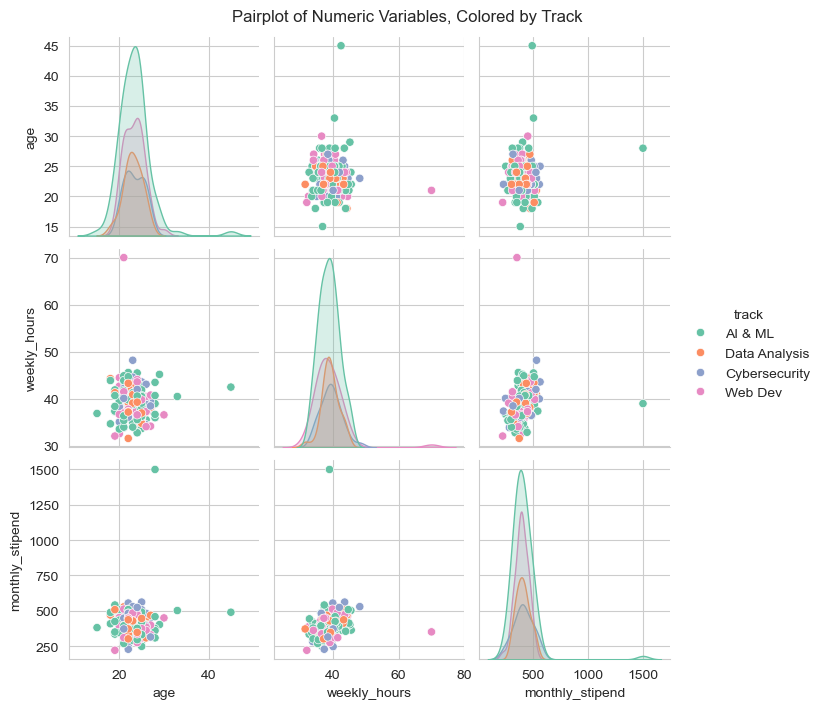

In [8]:
sns.pairplot(df, vars=["age", "weekly_hours", "monthly_stipend"], hue="track",
             palette="Set2", height=2.3)
plt.suptitle("Pairplot of Numeric Variables, Colored by Track", y=1.02)
plt.show()

<div style="border-left:5px solid #38BDF8; background-color:#eaf6ff; padding:10px 15px; margin:10px 0; border-radius:4px; color:#0c4a6e;">
<b>Note:</b> The diagonal cells show each variable's own distribution (like a KDE plot from Day 4); every off-diagonal cell is a scatter plot between two different variables. With <code>hue="track"</code>, each track gets its own color, letting you spot both overall relationships <i>and</i> whether they differ by group, in one chart.
</div>

<a id="section5"></a>
<h2 style="color:#BE185D; font-weight:bold; margin-top:30px;">5. Data Storytelling — Turning Analysis into a Narrative</h2>

<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">5.1 The deliverable is understanding, not charts</h3>

EDA produces charts, but the actual <b>deliverable is understanding, communicated clearly</b>. <b>Data storytelling</b> means turning the analysis into a narrative: what the data contains, what patterns and problems were found, and what they imply for modeling.

<div style="border-left:5px solid #BE185D; background-color:#fff0f6; padding:10px 15px; margin:10px 0; border-radius:4px; color:#7a0d3d;">
<b>Important:</b> This is the same communication skill emphasized throughout the program — <b>a finding nobody understands is not a finding.</b> A brilliant chart that nobody can interpret is worthless to a team or a client.
</div>

<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">5.2 What a good data story includes</h3>

<ul>
<li>What the dataset contains (rows, columns, what each represents)</li>
<li>Key distributions and any notable outliers (from univariate analysis)</li>
<li>The strongest relationships found (from bivariate/correlation analysis)</li>
<li>What these findings might mean for a future model or decision</li>
<li>Plain language throughout — a non-technical reader should be able to follow the main points</li>
</ul>

<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">5.3 The Full EDA Notebook</h3>

Week 2 closes with a complete EDA notebook that combines <b>everything</b>: descriptive statistics (Day 1), univariate distributions and outlier handling (Day 4), bivariate relationships and correlation (today), wrapped in a clear Markdown narrative. This notebook is the <b>template</b> for the EDA stage of every project through to the Phase 3 capstone.


<a id="section6"></a>
<h2 style="color:#BE185D; font-weight:bold; margin-top:30px;">6. Common Mistakes to Avoid</h2>

<div style="border-left:5px solid #BE185D; background-color:#fff0f6; padding:10px 15px; margin:10px 0; border-radius:4px; color:#7a0d3d;">
<b>Important:</b>
<ul>
<li><b>Claiming causation from correlation</b> — always the biggest risk in bivariate analysis; report relationships, not causes, unless you have experimental evidence.</li>
<li><b>Only checking Pearson correlation</b> — the default <code>.corr()</code> measures <i>linear</i> relationships; two variables can have a strong <i>non-linear</i> relationship (e.g. a U-shape) with a correlation near 0. Always look at the scatter plot too, not just the number.</li>
<li><b>Ignoring outliers before computing correlation</b> — a single extreme point can drastically inflate or deflate a correlation value; check for outliers (Day 4) before trusting a correlation heatmap.</li>
<li><b>Producing charts without a narrative</b> — a chart alone rarely speaks for itself; always pair visuals with a short, plain-language explanation of what they show.</li>
<li><b>Overloading a pairplot with too many variables</b> — beyond about 5-6 numeric variables, a pairplot becomes cluttered and hard to read; select the most relevant columns first.</li>
</ul>
</div>


<a id="section7"></a>
<h2 style="color:#BE185D; font-weight:bold; margin-top:30px;">7. Quick Reference — Cheat Sheet</h2>

<div style="border:1px solid #ccc; border-radius:6px; overflow:hidden;">
<table style="width:100%; border-collapse:collapse;">
<tr style="background-color:#1f2933; color:#FACC15;">
<th style="padding:8px; text-align:left;">Task</th>
<th style="padding:8px; text-align:left;">Code</th>
<th style="padding:8px; text-align:left;">Reveals</th>
</tr>
<tr><td style="padding:8px; border-top:1px solid #ccc;">Scatter plot</td><td style="padding:8px; border-top:1px solid #ccc;"><code>sns.scatterplot(data=df, x=, y=)</code></td><td style="padding:8px; border-top:1px solid #ccc;">Relationship between two numeric variables</td></tr>
<tr><td style="padding:8px; border-top:1px solid #ccc;">Scatter with groups</td><td style="padding:8px; border-top:1px solid #ccc;"><code>sns.scatterplot(..., hue="cat_col")</code></td><td style="padding:8px; border-top:1px solid #ccc;">Relationship, split by category</td></tr>
<tr><td style="padding:8px; border-top:1px solid #ccc;">Grouped box plot</td><td style="padding:8px; border-top:1px solid #ccc;"><code>sns.boxplot(data=df, x="cat", y="num")</code></td><td style="padding:8px; border-top:1px solid #ccc;">Numeric variable across categories</td></tr>
<tr><td style="padding:8px; border-top:1px solid #ccc;">Correlation value</td><td style="padding:8px; border-top:1px solid #ccc;"><code>df["a"].corr(df["b"])</code></td><td style="padding:8px; border-top:1px solid #ccc;">-1 to +1 strength of linear relationship</td></tr>
<tr><td style="padding:8px; border-top:1px solid #ccc;">Correlation matrix</td><td style="padding:8px; border-top:1px solid #ccc;"><code>df.corr(numeric_only=True)</code></td><td style="padding:8px; border-top:1px solid #ccc;">All pairwise correlations</td></tr>
<tr><td style="padding:8px; border-top:1px solid #ccc;">Correlation heatmap</td><td style="padding:8px; border-top:1px solid #ccc;"><code>sns.heatmap(corr, annot=True, cmap="coolwarm")</code></td><td style="padding:8px; border-top:1px solid #ccc;">All correlations, visualized at once</td></tr>
<tr><td style="padding:8px; border-top:1px solid #ccc;">Pairplot</td><td style="padding:8px; border-top:1px solid #ccc;"><code>sns.pairplot(df, hue="cat_col")</code></td><td style="padding:8px; border-top:1px solid #ccc;">Every numeric relationship at once</td></tr>
</table>
</div>


<a id="section8"></a>
<h2 style="color:#BE185D; font-weight:bold; margin-top:30px;">8. Hands-On Lab — Complete EDA Notebook</h2>

<div style="border-left:5px solid #FACC15; background-color:#fffbea; padding:10px 15px; margin:10px 0; border-radius:4px; color:#78350f;">
<b>Goal:</b> Assemble everything from all of Week 2 — statistics, probability-informed thinking, univariate distributions, outliers, and today's bivariate/correlation analysis — into one complete, narrated EDA notebook on the interns dataset.
</div>


<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">Step 1 — Scatter plots and grouped box plots for the most important variable pairs</h3>

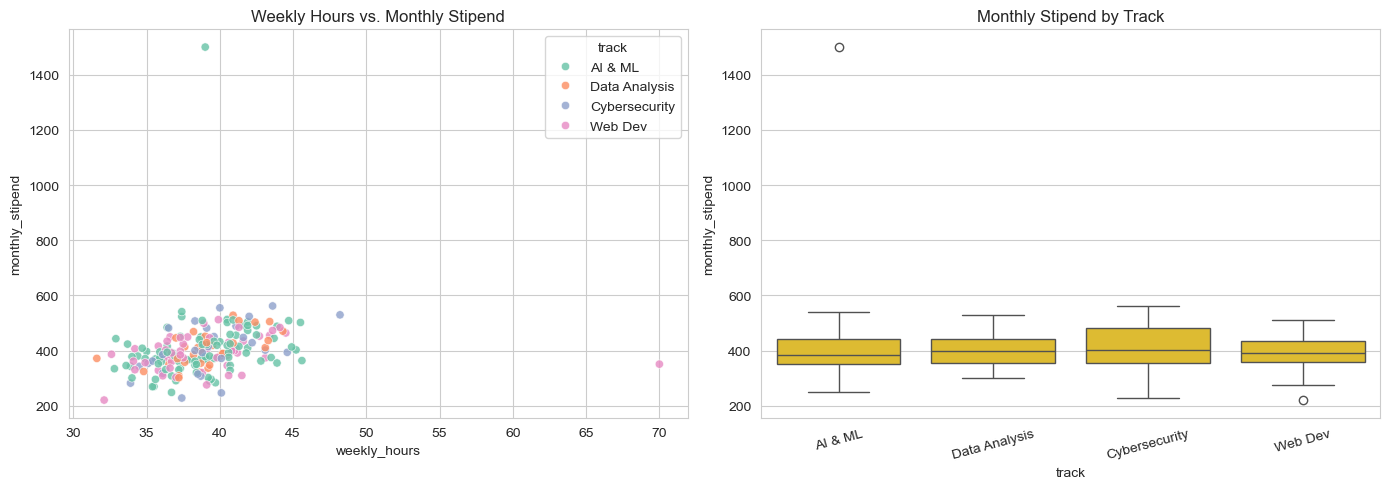

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=df, x="weekly_hours", y="monthly_stipend", hue="track",
                palette="Set2", alpha=0.8, ax=axes[0])
axes[0].set_title("Weekly Hours vs. Monthly Stipend")

sns.boxplot(data=df, x="track", y="monthly_stipend", color="#FACC15", ax=axes[1])
axes[1].set_title("Monthly Stipend by Track")
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">Step 2 — Compute the correlation matrix and visualize it as an annotated heatmap</h3>

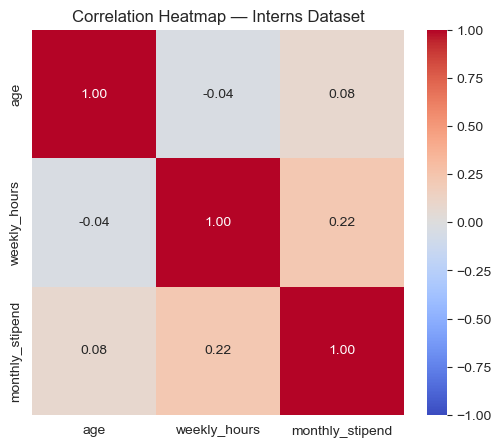

                      age  weekly_hours  monthly_stipend
age              1.000000      -0.03747         0.082767
weekly_hours    -0.037470       1.00000         0.219490
monthly_stipend  0.082767       0.21949         1.000000


In [10]:
corr_matrix = df[["age", "weekly_hours", "monthly_stipend"]].corr(numeric_only=True)

plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f")
plt.title("Correlation Heatmap — Interns Dataset")
plt.show()

print(corr_matrix)

<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">Step 3 — Identify the strongest relationships and state what they might mean for a future model</h3>

In [11]:
# Find the strongest off-diagonal correlation
corr_unstacked = corr_matrix.where(~np.eye(len(corr_matrix), dtype=bool)).unstack().dropna()
strongest = corr_unstacked.abs().sort_values(ascending=False)
print("Correlation strength ranking (strongest first):")
print(strongest)

Correlation strength ranking (strongest first):
weekly_hours     monthly_stipend    0.219490
monthly_stipend  weekly_hours       0.219490
age              monthly_stipend    0.082767
monthly_stipend  age                0.082767
age              weekly_hours       0.037470
weekly_hours     age                0.037470
dtype: float64


<div style="border-left:5px solid #BE185D; background-color:#fff0f6; padding:10px 15px; margin:10px 0; border-radius:4px; color:#7a0d3d;">
<b>Important — findings:</b>
<ul>
<li><b>weekly_hours &amp; monthly_stipend</b> show the strongest relationship in the dataset (moderate positive correlation) — if this pattern reflects a real policy (e.g. overtime pay), a future model predicting stipend would want <code>weekly_hours</code> as a key input feature.</li>
<li><b>age</b> shows very weak correlation with both other variables — suggesting age likely won't be a strong predictor for stipend or hours worked, at least on its own.</li>
<li>As emphasized in Section 3, this is a <b>relationship</b>, not proof of a <b>cause</b> — a hiring manager should investigate whether hours genuinely drive stipend, or whether both are driven by a third factor like role or seniority, before making policy decisions based on this alone.</li>
</ul>
</div>

<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">Step 4 — Assemble the full EDA (statistics, univariate, outliers, bivariate, correlation) into one narrated notebook</h3>

In [12]:
print("=" * 60)
print("WEEK 2 COMPLETE EDA SUMMARY -- Interns Dataset")
print("=" * 60)

print("\n--- 1. Descriptive Statistics (Day 1 concepts) ---")
print(df[["age", "weekly_hours", "monthly_stipend"]].describe())

print("\n--- 2. Univariate: Outlier Check (Day 4 concepts, IQR method) ---")
for col in ["age", "weekly_hours", "monthly_stipend"]:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    print(f"{col}: {len(outliers)} outlier(s)")

print("\n--- 3. Bivariate: Strongest Correlation (Day 5 concepts) ---")
print(f"weekly_hours vs monthly_stipend correlation: {df['weekly_hours'].corr(df['monthly_stipend']):.3f}")

print("\n--- 4. Categorical Balance ---")
print(df["track"].value_counts())

WEEK 2 COMPLETE EDA SUMMARY -- Interns Dataset

--- 1. Descriptive Statistics (Day 1 concepts) ---
              age  weekly_hours  monthly_stipend
count  200.000000    200.000000       200.000000
mean    23.265000     39.000500       402.624000
std      2.913282      3.734607       103.204514
min     15.000000     31.600000       220.800000
25%     21.000000     36.675000       354.900000
50%     23.000000     38.800000       392.500000
75%     25.000000     40.825000       446.100000
max     45.000000     70.000000      1500.000000

--- 2. Univariate: Outlier Check (Day 4 concepts, IQR method) ---
age: 2 outlier(s)
weekly_hours: 2 outlier(s)
monthly_stipend: 1 outlier(s)

--- 3. Bivariate: Strongest Correlation (Day 5 concepts) ---
weekly_hours vs monthly_stipend correlation: 0.219

--- 4. Categorical Balance ---
track
AI & ML          90
Web Dev          50
Data Analysis    31
Cybersecurity    29
Name: count, dtype: int64


<div style="border-left:5px solid #4ADE80; background-color:#eafff2; padding:10px 15px; margin:10px 0; border-radius:4px; color:#065f46;">
<b>Narrative summary (the "story"):</b> This dataset describes 200 interns across four tracks, with a fairly typical workweek (~39 hours) and stipend (~$400/month). Univariate analysis flagged three individual outliers worth a follow-up look, one of which (an unusually high stipend) looks like a possible data-entry error rather than a genuine value. Bivariate analysis found a moderate positive relationship between hours worked and stipend — the most actionable finding in the dataset — while age showed little relationship with either. The track distribution is imbalanced, with "AI &amp; ML" interns forming the largest group. Together, these findings suggest that any future model of intern stipend should treat <code>weekly_hours</code> as an important feature, treat <code>age</code> as likely unhelpful on its own, and should be built only after the suspicious stipend outlier is verified or corrected.
</div>

<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">Step 5 — Commit the finished EDA notebook to GitHub</h3>
<div style="border-left:5px solid #BE185D; background-color:#fff0f6; padding:10px 15px; margin:10px 0; border-radius:4px; color:#7a0d3d;">
<b>Important:</b> This last step happens in your terminal, not in the notebook itself:
</div>

In [13]:
# Run these commands in your terminal (not inside the notebook):
#
#   pip freeze > requirements.txt
#   git add Day5.ipynb requirements.txt
#   git commit -m "Week 2 Day 5: Correlation, bivariate EDA, and full EDA notebook"
#   git push
print("See the commands above -- run them in your terminal, in your project folder.")

See the commands above -- run them in your terminal, in your project folder.


<a id="section9"></a>
<h2 style="color:#BE185D; font-weight:bold; margin-top:30px;">9. Best Practices &amp; Reproducibility</h2>

<div style="border-left:5px solid #BE185D; background-color:#fff0f6; padding:10px 15px; margin:10px 0; border-radius:4px; color:#7a0d3d;">
<b>Important:</b> As always, fix a random seed wherever randomness is used: <code>np.random.seed(42)</code>, done at the top of this notebook — using the <i>same</i> seed as Day 4 so both notebooks describe the exact same dataset.
</div>

<div style="border-left:5px solid #4ADE80; background-color:#eafff2; padding:10px 15px; margin:10px 0; border-radius:4px; color:#065f46;">
<b>Tip:</b> A professional bivariate/correlation EDA checklist:
<ul>
<li>Look at the <b>scatter plot</b>, not just the correlation number — a non-linear pattern can hide from a correlation coefficient.</li>
<li>Check for <b>outliers</b> before trusting a correlation value — they can drastically distort it.</li>
<li>Never state or imply <b>causation</b> from a correlation alone.</li>
<li>End every EDA with a short, plain-language <b>narrative</b> — the charts support the story, they aren't the story themselves.</li>
</ul>
</div>


<a id="section10"></a>
<h2 style="color:#BE185D; font-weight:bold; margin-top:30px;">10. Summary — What I Learned Today</h2>

<div style="border-left:5px solid #4ADE80; background-color:#eafff2; padding:10px 15px; margin:10px 0; border-radius:4px; color:#065f46;">
<b>Tip:</b>
<ul>
<li><b>Bivariate analysis</b> examines relationships between two variables — <b>scatter plots</b> for two numeric variables, <b>grouped box plots</b> for a numeric variable across categories.</li>
<li><b>Correlation</b> measures the strength of a <i>linear</i> relationship on a scale from -1 to +1; a <b>correlation heatmap</b> shows every pairwise correlation in a dataset at once.</li>
<li><b>Correlation is not causation</b> — always report relationships, not causes, and consider possible confounding variables.</li>
<li><code>sns.pairplot()</code> scans every numeric relationship in a dataset simultaneously, useful early in EDA to decide where to look closer.</li>
<li><b>Data storytelling</b> turns analysis into a clear narrative — the actual deliverable of EDA is understanding, not just charts.</li>
<li>The <b>complete Week 2 EDA notebook</b> — combining statistics, univariate analysis, outlier handling, bivariate relationships, and correlation — is the template used for the EDA stage of every project through the Phase 3 capstone.</li>
</ul>
</div>
